## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


# sklearn functions for evaluating regressors
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, max_error, root_mean_squared_error, PredictionErrorDisplay 

# dummy models for baseline
from sklearn.dummy import DummyRegressor


## Preparing the data

In [3]:
# importing the data
df = pd.read_parquet("DKHousingPrices.parquet", engine='fastparquet')

In [4]:
#Dropping all rows with na
df = df.dropna(subset=["city", "quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "dk_ann_infl_rate%", "nom_interest_rate%", "yield_on_mortgage_credit_bonds%"])

#### Convert quarter from datetime to integer

In [5]:
#Convert a Period column to the number of days/months/years since a reference date
df["quarter"] = df["quarter"].astype("int64")

#Convert zip_code to categorical
df["zip_code"] = df["zip_code"].astype("category")

### Make dummy variables

In [6]:
# Due to computational limitations, we will sample 10% of the data for modeling
df = df.sample(frac=0.1, random_state=42).copy()
# We set drop_first=True to avoid the dummy variable trap
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "zip_code", "area", "nom_interest_rate%", "dk_ann_infl_rate%", "yield_on_mortgage_credit_bonds%"]], drop_first=True)
y = df["purchase_price"]
X.head()

,quarter,year_build,no_rooms,sqm,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,...,zip_code_9981,zip_code_9982,zip_code_9990,"area_Capital, Copenhagen",area_East & mid jutland,area_Fyn & islands,area_North Zealand,area_North jutland,area_Other islands,area_South jutland
465021,199,1974,5,129.0,0.00,0.76,1.35,False,False,False,...,False,False,False,False,False,False,True,False,False,False
742767,181,1968,6,148.0,0.00,0.45,2.78,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1167754,139,2006,3,128.0,2.00,1.15,5.26,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1051169,149,2003,5,149.0,3.75,1.69,5.70,False,False,False,...,False,False,False,False,False,False,False,False,False,True
412051,201,1968,4,86.0,0.00,0.42,1.10,False,False,False,...,False,False,False,False,True,False,False,False,False,False


## Feature importance testing

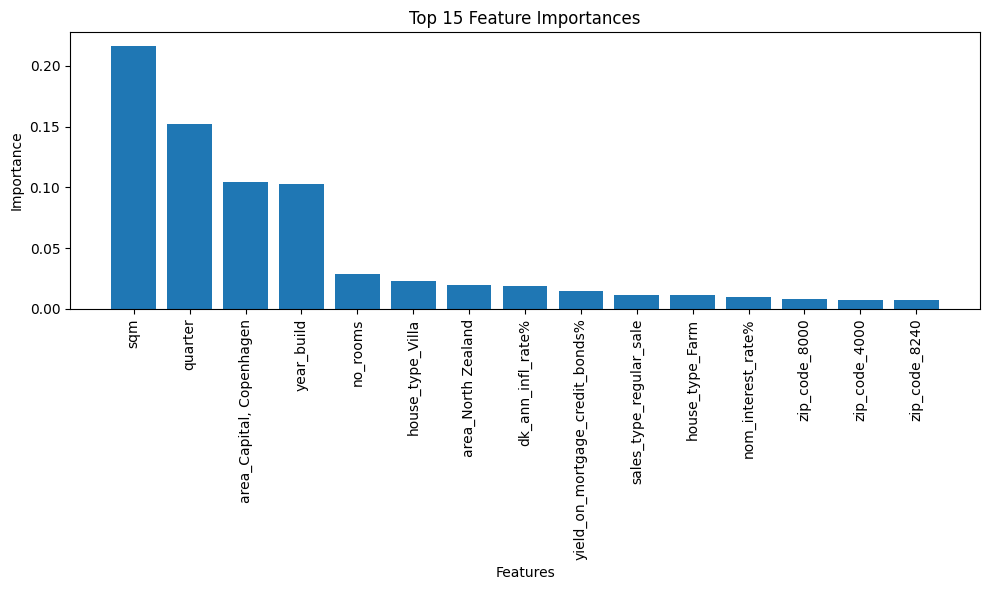

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Initialize a Random Forest classifier
clf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the classifier on the training data
clf.fit(X_train, y_train)

importances = clf.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

top_15_features = indices[:15]
# Get the top 15 feature names and importances
top_15_names = [X.columns[i] for i in top_15_features]
top_15_importances = importances[top_15_features]

# Create plot for top 15 features
plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances")
plt.bar(range(15), top_15_importances)
plt.xticks(range(15), top_15_names, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Setting the variables based off the feature importance test

In [8]:
X = X[top_15_names]
y = df["purchase_price"]
X.head()

,sqm,quarter,"area_Capital, Copenhagen",year_build,no_rooms,house_type_Villa,area_North Zealand,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,sales_type_regular_sale,house_type_Farm,nom_interest_rate%,zip_code_8000,zip_code_4000,zip_code_8240
465021,129.0,199,False,1974,5,True,True,0.76,1.35,True,False,0.00,False,False,False
742767,148.0,181,False,1968,6,True,False,0.45,2.78,True,False,0.00,False,False,False
1167754,128.0,139,False,2006,3,False,False,1.15,5.26,True,False,2.00,False,False,False
1051169,149.0,149,False,2003,5,True,False,1.69,5.70,True,False,3.75,False,False,False
412051,86.0,201,False,1968,4,False,False,0.42,1.10,True,False,0.00,False,False,False


### Training and test split

In [9]:
# Split the data into training and testing sets, the default is 75% train and 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Creating a baseline

This baselines is based on the mean value from the dataset

In [10]:
dm = DummyRegressor(strategy='mean')
dm.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [11]:
dm_y_pred = dm.predict(X_test)

In [12]:
print("Score on training set: {:.3f}".format(dm.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(dm.score(X_test, y_test)))

Score on training set: 0.000
Score on test set: -0.000


## Linear Regression Model

Make the training and testing split

In [13]:
lr = LinearRegression()
lr_y_pred = lr.fit(X_train, y_train).predict(X_test)

In [14]:
#Evaluate the model
print("Score on training set: {:.3f}".format(lr.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(lr.score(X_test, y_test)))

Score on training set: 0.334
Score on test set: 0.343


## Polynomial Regression Model

We use the code below to create polynomial features on the training data to the degree of 5. 

In [15]:
# Create polynomial features with degree 3
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [16]:
# Create and fit the model
poly_lr = LinearRegression()
pr_y_pred = poly_lr.fit(X_train_poly,y_train).predict(X_test_poly)

Evaluating the model

In [17]:
print("Score on training set: {:.3f}".format(poly_lr.score(X_train_poly, y_train)))
print("Score on test set: {:.3f}".format(poly_lr.score(X_test_poly, y_test)))

Score on training set: 0.495
Score on test set: 0.479


## Grid Search CV

In [ ]:
# Here we set up a grid search to find the best polynomial degree for our features.
# We define a parameter grid with degrees from 1 to 5.
param_grid = {
   'poly_features__degree': [1, 2, 3, 4, 5]
}

# creating the pipeline with PolynomialFeatures and LinearRegression
model = Pipeline([
   ('poly_features', PolynomialFeatures()),
   ('lin_reg', LinearRegression())
])

# set up GridSearchCV with the model and parameter grid. r2 is used as the scoring metric, and n_jobs=-1 allows for parallel processing across all available CPU cores.
grid_search = GridSearchCV(model, param_grid, scoring='r2', n_jobs=-1)

# fit the grid search to the training data
grid_search.fit(X_train, y_train)

# retrieve and print the scores for each iteration
cv_results = grid_search.cv_results_
for mean_score, params in zip(cv_results["mean_test_score"], cv_results["params"]):
   print(f"Mean R-squared for {params}: {mean_score}")

# retrieve the best hyperparameters and the corresponding best estimator
best_degree = grid_search.best_params_['poly_features__degree']
best_model = grid_search.best_estimator_

# print the best hyperparameters
print(f"Best Polynomial Degree: {best_degree}")

# evaluate the best model on the test data
test_score = best_model.score(X_test, y_test)
print(f"Test R-squared with best model: {test_score}")

## KNN Model

Fitting a KNeighborsRegressor and defining it as knn.

In [18]:
knn = KNeighborsRegressor()
knn_y_pred = knn.fit(X_train, y_train).predict(X_test)

In [19]:
# print scores
print("Score on training set: {:.3f}".format(knn.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(knn.score(X_test, y_test)))

Score on training set: 0.423
Score on test set: 0.134


Using StandardScaler to standardize the scales of attributes.

In [20]:
scaler = StandardScaler() # define the scaler
X_train_scaled = scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_scaled = scaler.transform(X_test) # apply to the testing feature matrix

Fitting a KNeighborsRegressor and defining it as knn_scaled.

In [21]:
# Create and fit the model with 30 neighbors, Manhattan distance (p=1), and distance-based weighting
knn_scaled = KNeighborsRegressor(n_neighbors=30, p=1, weights='distance')
knn_standard_y_pred = knn_scaled.fit(X_train_scaled, y_train).predict(X_test_scaled)

In [22]:
print("Score on training set: {:.3f}".format(knn_scaled.score(X_train_scaled, y_train)))
print("Score on test set: {:.3f}".format(knn_scaled.score(X_test_scaled, y_test)))

Score on training set: 0.999


KeyboardInterrupt: 

Applying RobustScaler.

In [27]:
robust_scaler = RobustScaler() # define the scaler
X_train_robust = robust_scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_robust = robust_scaler.transform(X_test) # apply to the testing feature matrix

Fitting a KNeighborsRegressor and defining it as knn_robust.

In [ ]:
# Create and fit the model with 48 neighbors, Euclidean distance (p=2), and distance-based weighting
knn_robust = KNeighborsRegressor(n_neighbors=48, p=2, weights='distance')
knn_robust_y_pred = knn_robust.fit(X_train_robust, y_train).predict(X_test_robust)

In [29]:
print("Score on training set: {:.3f}".format(knn_robust.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(knn_robust.score(X_test_robust, y_test)))

Score on training set: 0.999
Score on test set: 0.462


Setting up a parameter grid.

In [ ]:
param_grid = {
   'n_neighbors': [1, 5, 10, 20, 30],
   'weights': ['uniform', 'distance'],
   'p': [1, 2], # 1 for manhattan vs. 2 for euclidean distance
}

Using GridSearchCV.

In [ ]:
grid_search = GridSearchCV(estimator=knn_robust,
                          param_grid=param_grid,
                          cv=5,  # number of folds to use
                          scoring='r2',  # evaluation metric
                          return_train_score=True,  # whether to return training scores in the output.
                          verbose=3)  # controls the verbosity of the output (i.e., how much output to print)

# fit the model with training data X_train_robust and target y_train
grid_search.fit(X_train_robust, y_train)  

In [33]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

In [34]:
best_knn = grid_search.best_estimator_
print("Score on training set: {:.3f}".format(best_knn.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(best_knn.score(X_test_robust, y_test)))

Using GridSearchCV with scaling.

In [ ]:
# defining pipeline with scaler and the KNN regressor
pipe = Pipeline([
   ('scaler', StandardScaler()),
   ('knn', KNeighborsRegressor())
])

param_grid = {
   'scaler': [StandardScaler(), RobustScaler(), 'passthrough'],  # different scaling methods (`passthrough` means no scaling)
   'knn__n_neighbors': [3, 6, 12, 24, 48, 96],
   'knn__weights': ['distance', 'uniform'],
   'knn__p': [1, 2],
}

# setting up GridSearchCV
grid_search = GridSearchCV(
   estimator=pipe,
   param_grid=param_grid,
   scoring='r2',
   return_train_score=True,
   verbose=3
)

#fitting model with the original training data
grid_search.fit(X_train, y_train)

In [36]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

## Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=150,        
    max_depth=20,          
    min_samples_leaf=5,      
    max_features="sqrt",     
    n_jobs=-1,
    random_state=42,
)

In [38]:
# Fit the model to the training data
rf_y_pred = rf.fit(X_train, y_train).predict(X_test)

In [39]:
print("Score on training set: {:.3f}".format(rf.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(rf.score(X_test, y_test)))

Score on training set: 0.608
Score on test set: 0.495


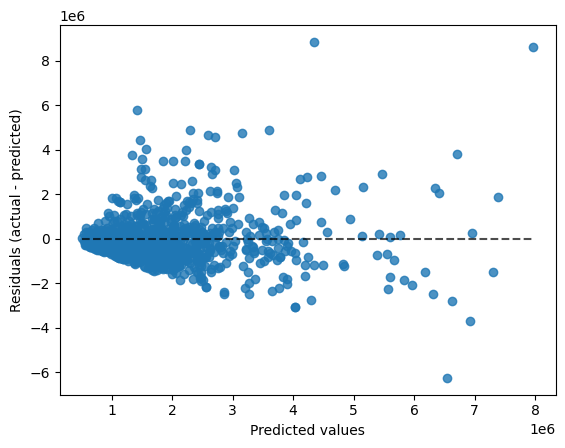

In [119]:
display = PredictionErrorDisplay.from_predictions(y_test, rf_y_pred)

## Evaluation
This will be done based on MAE, MAPE, MSE, RMSE and Max

In [40]:
# this is a function that takes actual y values (y_true) and predicted y values (y_pred) and calculates MAE, MAPE, MSE, and RMSE
def get_metrics(y_true, y_pred):
    
    # MAE: the average of the absolute differences between the actual values and the predicted values
    mae = mean_absolute_error(y_true, y_pred)
    
    # MAPE: the average absolute percentage difference between the actual and predicted values
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # MSE: the average of the squared differences between the actual values and the predicted values
    mse = mean_squared_error(y_true, y_pred)
    
    # RMSE: the square root of MSE
    rmse = root_mean_squared_error(y_true, y_pred)

    # Max error: the average absolute percentage difference between the actual and predicted values
    max = max_error(y_true, y_pred)
    
    # return all four metrics
    return mae, mape, mse, rmse, max

In [41]:
# calculate the metrics for each model using our `get_metrics` function.
dm_metrics = get_metrics(y_test, dm_y_pred)  # for dummy regressor
lr_metrics = get_metrics(y_test, lr_y_pred)  # for linear regression
pr_metrics = get_metrics(y_test, pr_y_pred)  # for polynomial regression
kn_metrics = get_metrics(y_test, knn_y_pred)  # for KNN regressor
kn_standard_metrics = get_metrics(y_test, knn_standard_y_pred)  # for KNN regressor with standard scaling
kn_robust_metrics = get_metrics(y_test, knn_robust_y_pred)  # for KNN regressor with robust scaling
rf_metrics = get_metrics(y_test, rf_y_pred)  # for random forest regressor

In [42]:
# create a dataframe (table) to store and display the computed metrics where each row represents a different model and each column represents a different metric
results = pd.DataFrame({
    'Model': ['Dummy', 'Linear Regression', 'Polynomial Regression', 'KNN', 'KNN_standardscaler', 'KNN_robustscaler', 'Random Forest'],  # model names
    'MAE': [dm_metrics[0], lr_metrics[0], pr_metrics[0], kn_metrics[0], kn_standard_metrics[0], kn_robust_metrics[0], rf_metrics[0]],  # MAE values for each model
    'MAPE': [dm_metrics[1], lr_metrics[1], pr_metrics[1], kn_metrics[1], kn_standard_metrics[1], kn_robust_metrics[1], rf_metrics[1]],  # MAPE values for each model
    'MSE': [dm_metrics[2], lr_metrics[2], pr_metrics[2], kn_metrics[2], kn_standard_metrics[2], kn_robust_metrics[2], rf_metrics[2]],  # MSE values for each model
    'RMSE': [dm_metrics[3], lr_metrics[3], pr_metrics[3], kn_metrics[3], kn_standard_metrics[3], kn_robust_metrics[3], rf_metrics[3]], # RMSE values for each model
    'Max': [dm_metrics[4], lr_metrics[4], pr_metrics[4], kn_metrics[4], kn_standard_metrics[4], kn_robust_metrics[4], rf_metrics[4]] # Max error values for each model
})

# display results
results

,Model,MAE,MAPE,MSE,RMSE,Max
0,Dummy,1.187342e+06,1.097294,3.186839e+12,1.785172e+06,3.058376e+07
1,Linear Regression,9.179024e+05,0.738023,2.094882e+12,1.447371e+06,2.599970e+07
2,Polynomial Regression,7.942936e+05,0.634216,1.659446e+12,1.288195e+06,2.466674e+07
3,KNN,1.034250e+06,0.814168,2.761207e+12,1.661688e+06,2.939149e+07
4,KNN_standardscaler,7.424725e+05,0.578710,1.655993e+12,1.286854e+06,2.709186e+07
5,KNN_robustscaler,7.481596e+05,0.582585,1.715231e+12,1.309668e+06,2.818005e+07
6,Random Forest,7.476871e+05,0.600075,1.608478e+12,1.268258e+06,2.768532e+07


**RANDOM FOREST TEST PREDICTION**

In [31]:
# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Define temporal split
train_mask = df["date"].dt.year < 2024
test_mask  = df["date"].dt.year == 2024

# Split features and target using time-based masks
X_train_time = X.loc[train_mask]
y_train_time = y.loc[train_mask]

X_test_time  = X.loc[test_mask]
y_test_time  = y.loc[test_mask]

In [32]:
# Refit Random Forest on pre-2024 data only
rf.fit(X_train_time, y_train_time)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=150, n_jobs=-1, random_state=42)

In [33]:
# Predict prices for 2024 observations only
rf_pred_2024 = rf.predict(X_test_time)

In [34]:
rf_results = pd.DataFrame({
    "actual_price": y_test_time.values,
    "predicted_price": rf_pred_2024
})

rf_results["abs_error"] = (
    rf_results["predicted_price"] - rf_results["actual_price"]
).abs()

rf_results["pct_error"] = (
    (rf_results["predicted_price"] - rf_results["actual_price"])
    / rf_results["actual_price"]
) * 100

rf_results["abs_pct_error"] = rf_results["pct_error"].abs()

In [35]:
print("\nError summary (Random Forest, 2024 only):")
print(
    rf_results[["abs_error", "abs_pct_error"]]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
)

thresholds = [5, 10, 15, 20, 25, 50]
for t in thresholds:
    share = (rf_results["abs_pct_error"] <= t).mean() * 100
    print(f"Within ±{t}%: {share:.1f}%")


Error summary (Random Forest, 2024 only):
          abs_error  abs_pct_error
count  5.916000e+03    5916.000000
mean   9.509329e+05      51.548673
std    1.142385e+06      85.367648
min    1.499393e+02       0.014079
50%    6.189659e+05      30.802422
75%    1.154152e+06      52.786863
90%    2.095877e+06     110.768795
95%    3.025501e+06     178.620069
99%    5.318632e+06     382.115096
max    1.884757e+07    2295.670835
Within ±5%: 8.1%
Within ±10%: 16.5%
Within ±15%: 24.9%
Within ±20%: 33.2%
Within ±25%: 41.1%
Within ±50%: 72.5%


In [36]:
# Single random 2024 house prediction
case_idx = X_test_time.sample(1).index[0]

X_case = X_test_time.loc[[case_idx]]
actual = y_test_time.loc[case_idx]
pred   = rf.predict(X_case)[0]

print("\nSingle 2024 house prediction (Random Forest):")
print(f"Actual:    {actual:,.0f} kr.")
print(f"Predicted: {pred:,.0f} kr.")
print(f"Error:     {pred-actual:,.0f} kr. ({(pred-actual)/actual*100:.2f}%)")


Single 2024 house prediction (Random Forest):
Actual:    1,430,000 kr.
Predicted: 1,524,309 kr.
Error:     94,309 kr. (6.60%)


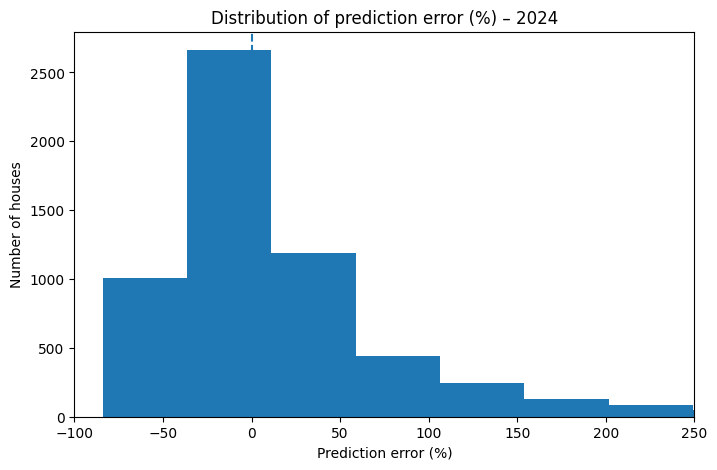

In [37]:
plt.figure(figsize=(8,5))
plt.hist(rf_results["pct_error"], bins=50)
plt.axvline(0, linestyle="--")
plt.xlim(-100, 250)
plt.xlabel("Prediction error (%)")
plt.ylabel("Number of houses")
plt.title("Distribution of prediction error (%) – 2024")
plt.show()